### Smoothing / Low-Pass Filters
- Mean (Averaging) filter
- Weighted Mean filter
- Gaussian filter

### Sharpening / Edge Detection Filters
- Laplacian
- Roberts
- Prewitt
- Sobel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and Display the Input Image

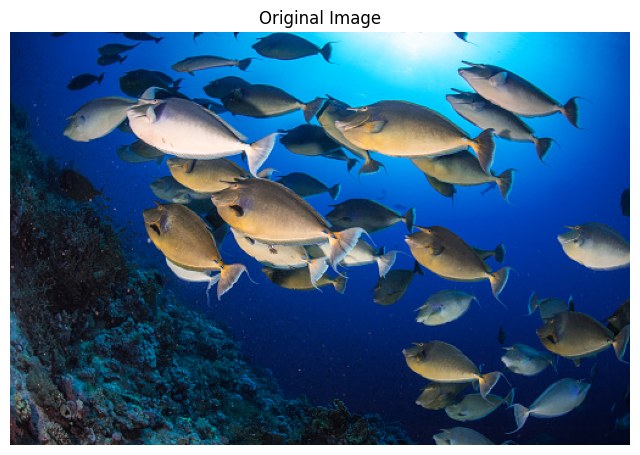

In [ ]:
image_path = "E:\DSIP\VS Py\Experiment 9\image.jpg"
image = cv2.imread(image_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

## 2. Mean / Averaging Smoothing Filter

The mean filter replaces each pixel by the average of its neighborhood. It reduces random noise but can blur edges.

For a 3×3 mean filter, every coefficient is `1/9`.

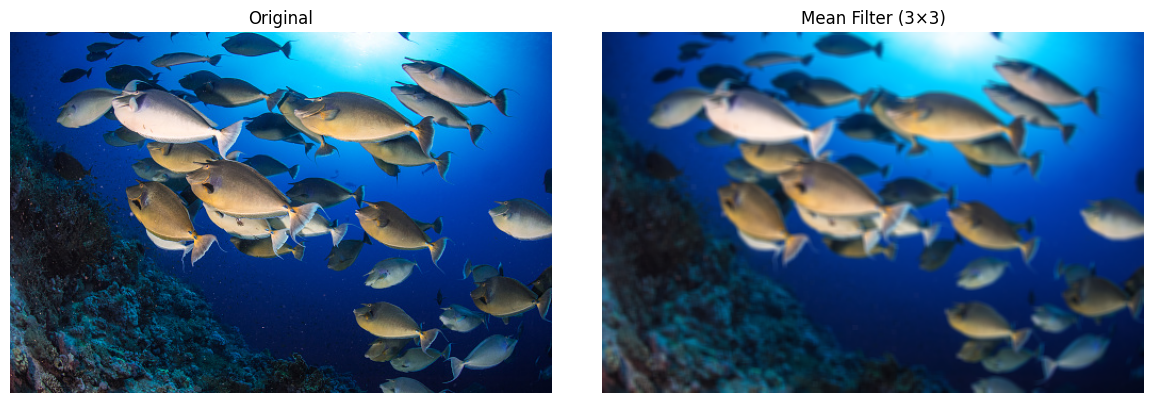

In [39]:
mean_3x3 = cv2.blur(image, (5, 5)) # use 3*3, 5*5, etc

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(mean_3x3, cv2.COLOR_BGR2RGB))
plt.title('Mean Filter (3×3)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Weighted Mean Smoothing Filter

A weighted mean gives more importance to selected pixels. Here, the center pixel receives a larger weight.

# Syntax:
cv2.filter2D(source_image, ddepth, kernel)

source_image → Input image on which the filter is applied

ddepth → Depth/data type of the output image
-1 → Same depth as input image
0 → CV_8U  (8-bit unsigned integer, range 0–255)
1 → CV_8S  (8-bit signed integer, range -128 to 127)
2 → CV_16U (16-bit unsigned integer)
3 → CV_16S (16-bit signed integer)
4 → CV_32S (32-bit signed integer)
5 → CV_32F (32-bit floating point)
6 → CV_64F (64-bit floating point)
kernel → Filter/mask used for convolution

weighted_mean = cv2.filter2D(image, -1, weighted_kernel)

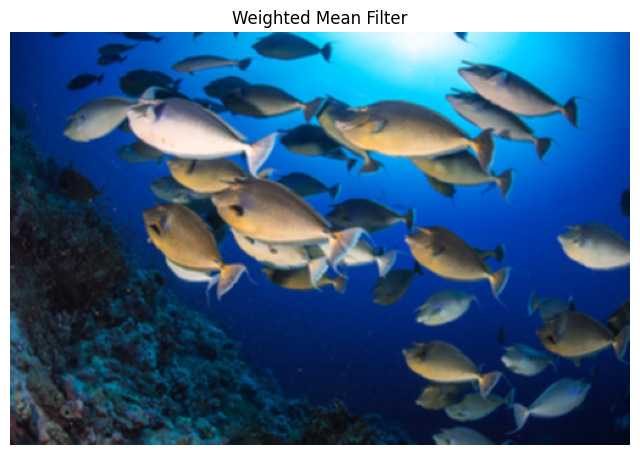

In [40]:
weighted_kernel = np.asarray([
    [1, 1, 1],
    [1, 2, 1],
    [1, 1, 1]
], dtype=np.float32)

weighted_kernel = weighted_kernel / 10

weighted_mean = cv2.filter2D(image, -1, weighted_kernel)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(weighted_mean, cv2.COLOR_BGR2RGB))
plt.title('Weighted Mean Filter')
plt.axis('off')
plt.show()

## 4. Gaussian Smoothing Filter

Gaussian filtering assigns weights according to a Gaussian distribution. It generally produces smoother results than a simple mean filter while preserving image structure better.


Small σ: weights concentrated near the center means less smoothing and more details preserved
Large σ: weights spread across the neighborhood means more smoothing and more details removed



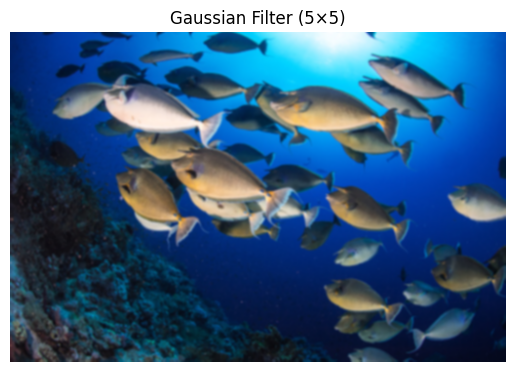

In [41]:
# sigmaX = 0 → OpenCV automatically calculates sigma
g0 = cv2.GaussianBlur(image, (5, 5), sigmaX=0)

# sigmaX = 1 → manually specify σ = 1
g1 = cv2.GaussianBlur(image, (5, 5), sigmaX=1)

# sigmaX = 2 → manually specify σ = 2
g2 = cv2.GaussianBlur(image, (5, 5), sigmaX=2)

plt.imshow(cv2.cvtColor(g0, cv2.COLOR_BGR2RGB))
plt.title('Gaussian Filter (5×5)')
plt.axis('off')
plt.show()

# Sharpening and Edge Detection Filters

The following operators highlight intensity changes and edges.

## 5. Laplacian Filter

The Laplacian is a second-order derivative operator. It detects rapid intensity changes in multiple directions.

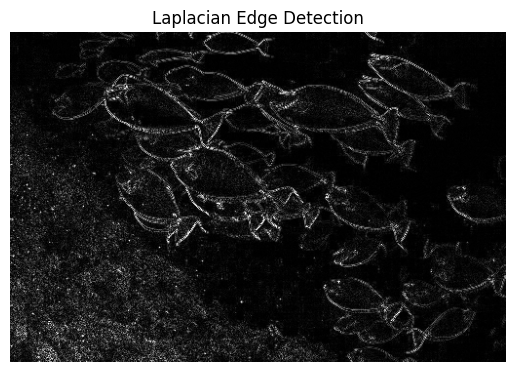

In [42]:
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
# CV_64F → allows positive, negative, and decimal values produced by the Laplacian derivative

# Convert signed Laplacian values to positive magnitudes and 8-bit format for visualization
laplacian_abs = cv2.convertScaleAbs(laplacian)

plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')
plt.show()

## 6. Roberts Cross Operator

Roberts uses two 2×2 kernels to estimate diagonal intensity changes.

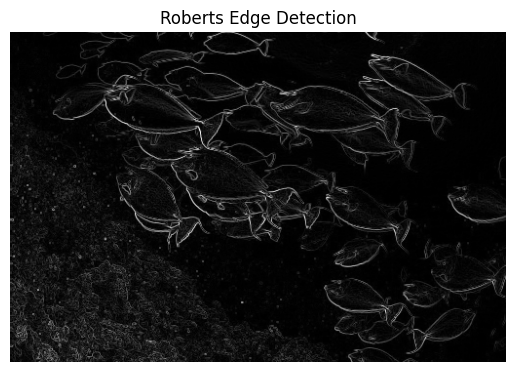

In [43]:
roberts_x = np.asarray([
    [1, 0],
    [0, -1]
], dtype=np.float32)

roberts_y = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

gx = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, roberts_x)
gy = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, roberts_y)

roberts = cv2.magnitude(gx, gy)
roberts = cv2.normalize(roberts, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(roberts, cmap='gray')
plt.title('Roberts Edge Detection')
plt.axis('off')
plt.show()

## 7. Prewitt Operator

Prewitt uses horizontal and vertical 3×3 derivative masks. The gradient magnitude combines both directions.

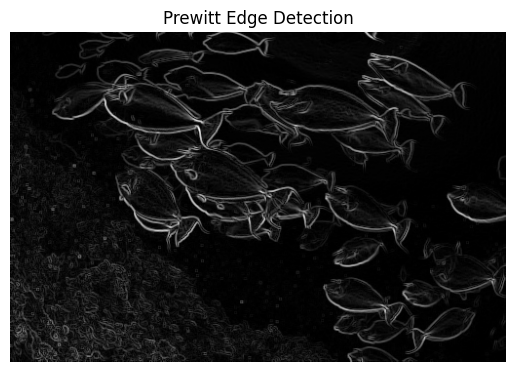

In [44]:
#Vertical Kernel
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# Horizontal Kernel
prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

px = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, prewitt_x)
py = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, prewitt_y)

prewitt = cv2.magnitude(px, py)

prewitt = cv2.normalize(prewitt, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

## 8. Sobel Operator

Sobel combines differentiation with smoothing and uses 3×3 kernels to estimate horizontal and vertical gradients.

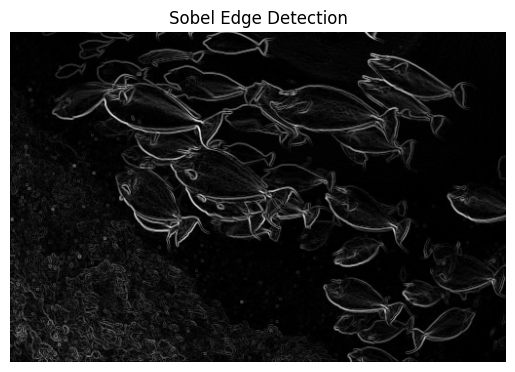

In [45]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))

sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.show()

## 9. Compare All Filters


# 10. How to Create and Apply a Custom Filter

A custom filter is simply a user-defined matrix called a **kernel** or **mask**. The kernel is moved across the image and multiplied with the corresponding neighborhood pixels.

OpenCV's `cv2.filter2D()` can apply the custom kernel directly.

Custom kernel:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


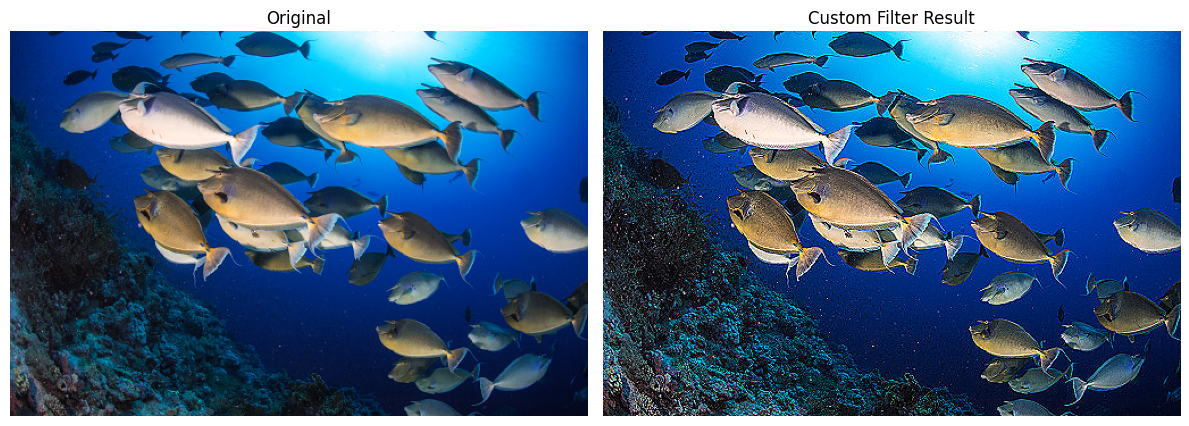

In [46]:
# Example custom sharpening kernel
custom_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

custom_filtered = cv2.filter2D(image, -1, custom_kernel)

print('Custom kernel:')
print(custom_kernel)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(custom_filtered, cv2.COLOR_BGR2RGB))
plt.title('Custom Filter Result')
plt.axis('off')

plt.tight_layout()
plt.show()

## 11. Experiment with Your Own Custom Kernel

Change the values in `my_kernel` and run the cell again. The kernel must normally have odd dimensions such as 3×3 or 5×5.

Custom kernel used:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


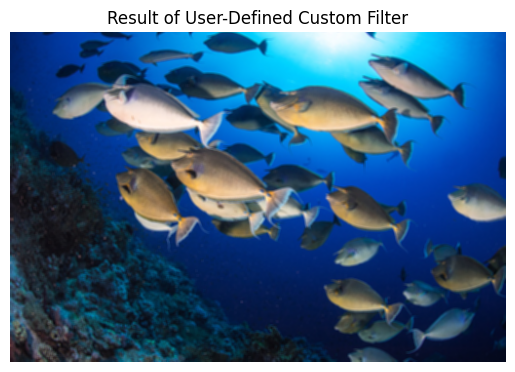

In [47]:
# Try changing these values to design your own filter
my_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32)

# Normalize if the filter is intended to average pixels
my_kernel = my_kernel / my_kernel.sum()

custom_result = cv2.filter2D(image, -1, my_kernel)

print('Custom kernel used:')
print(my_kernel)

plt.imshow(cv2.cvtColor(custom_result, cv2.COLOR_BGR2RGB))
plt.title('Result of User-Defined Custom Filter')
plt.axis('off')
plt.show()

# 13. Save All Important Results


In [48]:
cv2.imwrite('mean_filter.jpg', mean_3x3)
cv2.imwrite('weighted_mean_filter.jpg', weighted_mean)
cv2.imwrite('gaussian_filter.jpg', g0)
cv2.imwrite('laplacian.jpg', laplacian_abs)
cv2.imwrite('roberts.jpg', roberts)
cv2.imwrite('prewitt.jpg', prewitt)
cv2.imwrite('sobel.jpg', sobel_magnitude)
cv2.imwrite('custom_filter.jpg', custom_filtered)

print('All filter results have been saved.')

All filter results have been saved.
